<h1><center>Laboratorio 4: EDA en Pandas 🐼</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

### Cuerpo Docente:

- Profesores: Pablo Badilla, Diego Cortez
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Javier Cruz Araneda
- Nombre de alumno 2: Enzo Toledo Venegas


### **Link de repositorio de GitHub:** `https://github.com/enzo-toledo/MDS7202`


## Reglas:

- **Grupos de 2 personas**
- Asistencia **obligatoria** a instrucciones del lab (viernes 16.15). Luego, pueden quedarse trabajando en las salas o irse.
- **No se revisarán entregas de personas ausentes**. 
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibidas las copias. 
- Pueden usar cualquer matrial del curso que estimen conveniente.

### Objetivos principales del laboratorio

- Aplicar los paradigmas y buenas prácticas de programación vistas hasta este momento.
- Utilizar las funciones de la librería `pandas` para realizar análisis exploratorio de datos
- Aplicar principios de visualización de datos vistos en clases para mostrar patrones en los datos


El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas de `pandas`.

## Descripción del laboratorio.

### Importamos librerias utiles 😸

In [1]:
!uv pip install missingno

Using Python 3.14.3 environment at: C:\Users\Javier\Desktop\MDS7202\.venv
Checked 1 package in 10ms


In [2]:
# Libreria Core del lab.

# Libreria para plotear
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import plotly.express as px
from IPython.display import Markdown, display
from scipy import stats

# Segmentación de Clientes en Tienda de Retail 🛍️

<p align="center">
  <img width=300 src="https://s1.eestatic.com/2018/04/14/social/la_jungla_-_social_299733421_73842361_854x640.jpg">
</p>

## 1.1 Cargar dataset [0.5 puntos]

Mr. Lepin Mora quien es el gerente de una cotizada tienda de retail en Europa, les solicita si pueden analizar los datos de algunas de sus tiendas.

Para esto, el área de ventas les entrega el 2 archivos: `online_retail_II.pickle` y `online_retail_I.pickle`.
- Cargue ambas fuentes y asegúrese que las columnas son del tipo correcto como en el ejemplo de df_retail_1 visualizando los datos para determinar el tipo. Para fechas, puede usar `'datetime64[ns]'`
- Combine los dataframes en uno solo. ¿Qué función debe utilizar en este caso?
- Señale las columnas que componen el dataset combinado, el tipo de variable presente en cada columna y comente que representa cada una de estas.

**Respuesta:**

In [3]:
df_retail_1 = pd.read_pickle("online_retail_I.pickle")
df_retail_1 = df_retail_1.astype(
    {
        "Invoice": "category",
        "StockCode": "category",
        "Description": str,
        "Customer ID": "category",
    }
)
df_retail_1.head()

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085.0,United Kingdom


In [4]:
df_retail_2 = pd.read_pickle("online_retail_II.pickle")
df_retail_2 = df_retail_2.astype(
    {
        "Invoice": "category",
        "InvoiceDate": "datetime64[ns]",
    }
)
df_retail_2.head()

,Invoice,InvoiceDate
0,489434,2009-12-01 07:45:00
1,489435,2009-12-01 07:46:00
2,489436,2009-12-01 09:06:00
3,489437,2009-12-01 09:08:00
4,489438,2009-12-01 09:24:00


In [5]:
invoice1 = df_retail_1["Invoice"]
invoice2 = df_retail_2["Invoice"]

print("Filas en df_retail_1:", len(df_retail_1))
print("Filas en df_retail_2:", len(df_retail_2))
print(f"df_retail_2 tiene solo el {len(df_retail_2) / len(df_retail_1) * 100:.2f}% de las filas de df_retail_1")

Filas en df_retail_1: 525461
Filas en df_retail_2: 28816
df_retail_2 tiene solo el 5.48% de las filas de df_retail_1


> **Desarrollo:** Notemos que la columna común entre los dataframes es `Invoice`, sin embargo, el primero tiene muchas mas columnas que el segundo. Así, el segundo dataframe entrega información complementaria para algunas filas de datos, por tanto debemos mezclar o fusionarlos considerando el primero como base y así no perder información. Para esto basta usar merge con left para complementar los dataframes.

In [6]:
# Usamos merge left para complementar la información del primer dataframe sin perder filas en el primero ni generar demasiados NaN.
df_retail = pd.merge(df_retail_1, df_retail_2, on="Invoice", how="left")
print("Filas en df_retail:", len(df_retail))
print("Nuevas filas añadidas:", len(df_retail) - len(df_retail_1))
df_retail.head()

Filas en df_retail: 525461
Nuevas filas añadidas: 0


,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,InvoiceDate
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085.0,United Kingdom,2009-12-01 07:45:00
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,2009-12-01 07:45:00
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,2009-12-01 07:45:00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,13085.0,United Kingdom,2009-12-01 07:45:00
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085.0,United Kingdom,2009-12-01 07:45:00


In [7]:
df_retail.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  category      
 1   StockCode    525461 non-null  category      
 2   Description  522533 non-null  str           
 3   Quantity     525461 non-null  int64         
 4   Price        525461 non-null  float64       
 5   Customer ID  417534 non-null  category      
 6   Country      525461 non-null  object        
 7   InvoiceDate  525461 non-null  datetime64[ns]
dtypes: category(3), datetime64[ns](1), float64(1), int64(1), object(1), str(1)
memory usage: 24.5+ MB


> **Observación:** Existen algunos valores negativos en Price y Quantity junto a algunos tags en Invoice, por tanto, esto
> puede indicar algún tipo de transacción cancelada, devolución, sobredemanda, etc... Pero esto se abordará luego, por ahora
> se definen las columnas según lo que debiera ser su significado más lógico:

| # | Columna [Tipo] | Descripción |
| :--- | :--- | :--- |
| 1 | **Invoice** [category] | Identificador único de la transacción/factura (ojo, no igual que ID único por fila!)|
| 2 | **StockCode** [category] | Código identificador del producto (SKU) |
| 3 | **Description** [str] | Nombre o descripción textual del producto asociado al `StockCode`. |
| 4 | **Quantity** [int64] | Cantidad de unidades del producto |
| 5 | **Price** [float64] | Precio del producto en la transacción |
| 6 | **Customer ID** [category] | Identificador del cliente que realizó la compra|
| 7 | **Country** [object] | País de origen del cliente o de la tienda asociada a la transacción |
| 8 | **InvoiceDate** [datetime64[ns]] | Fecha y hora en que se emitió la factura/transacción |

## 1.2 Analisís Explotatorio de los Datos [0.5 puntos] 

En base a la primera visualización del dataset, *Don Mora* le solicita que realicen un análisis exploratorio de los datos, para esto les deberán realizar un análisis univariado y multivariado. De la revisión, ustedes deben explicar potenciales anomalías visualizadas y señalar si existe la necesidad de realizar una limpieza de datos.

Explique a que nos referimos con análisis univariable, multivariable y de datos faltantes. ¿Qué beneficios nos otorga estudiar estos datos?. Sea conciso con su respuesta y no escriba mas de 5 líneas para su respuesta.

**Respuesta a la Pregunta:**

> El **análisis univariable** corresponde a estudiar el tipo, comportamiento o distribución de una única variable de forma aislada, mientras que el **análisis multivariable** estudia las correlaciones y causalidades que pueden existir entre múltiples variables principalmente desde el punto de vista estadístico. Finalmente, el **análisis de datos faltantes** permite identificar ausencia de información en ciertas columnas o filas mediante la detección de valores nulos (NaN). El estudio de los datos bajo estos tipos de análisis permite detectar outliers, descubrir y/o entender patrones en los datos y permiten identificar la mejor forma de realizar una limpieza de los mismos.

### 1.2.1 Análisis Univariado [1.5 Puntos]

A continuación, se le presentan dos funciones para analizar los datos que componen un dataframe. La primera de estas es la función ``profile_serie()`` la cual recibe una serie y le entrega un análisis detallado de los datos que conforman dicha serie. 

Ejecute la funcion ``profile_serie()`` sobre cada serie para realizar un análisis univariado de estas. A continuación, comente acerca de el comportamiento de cada variable según las estadísticas descriptivas y los gráficos generados.

In [8]:
from pandas.api.types import is_datetime64_any_dtype, is_numeric_dtype, is_timedelta64_dtype


def profile_serie(serie_in, n_samples=1000, random_state=42):
    serie = serie_in.copy()

    profile = pd.Series(dtype="object")
    profile["Type"] = serie.dtype
    profile = pd.concat([profile, serie.describe()])

    # profile = pd.Series([])

    if is_numeric_dtype(serie):
        profile["Negative"] = (serie < 0).sum()
        profile["Negative (%)"] = str(round((serie < 0).sum() / len(serie) * 100, 2)) + " %"
        profile["Zeros"] = (serie == 0).sum()
        profile["Zeros (%)"] = str(round((serie == 0).sum() / len(serie) * 100, 2)) + " %"
        profile["Kurt"] = serie.kurt()
        profile["Skew"] = serie.skew()

    profile[" "] = " "  # espacio

    profile["Missing cells"] = serie.isnull().sum()
    profile["Missing cells (%)"] = str(round(serie.isnull().sum() / len(serie) * 100, 2)) + " %"
    profile["Duplicate rows"] = serie.duplicated(False).sum()
    profile["Duplicate rows (%)"] = str(round(serie.duplicated(False).sum() / len(serie) * 100, 2)) + " %"
    profile["Total size in memory"] = str(serie.memory_usage(index=True)) + " bytes"

    # profile = pd.concat([profile, description])

    profile = profile.rename(
        index={
            "count": "Number of observations",
            "mean": "Mean",
            "std": "Std",
            "min": "Min",
            "max": "Max",
            "unique": "Unique",
            "top": "Top",
            "freq": "Freq",
        }
    )
    no_outliers_fig = None

    if is_numeric_dtype(serie):
        sampled_serie = serie.sample(n_samples, random_state=random_state)
        fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name} - With Outliers")

        no_outliers = sampled_serie.loc[(np.abs(stats.zscore(sampled_serie)) < 3)]
        # zscore = https://es.wikipedia.org/wiki/Unidad_tipificada

        no_outliers_fig = px.histogram(no_outliers, marginal="box", title=f"{serie.name} - Without Outliers")

    elif is_datetime64_any_dtype(serie) or is_timedelta64_dtype(serie):
        sampled_serie = serie.sample(n_samples, random_state=random_state)
        fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name}")

    else:
        count = serie.value_counts()[0:100].reset_index().rename(columns={"count": "Count"})
        fig = px.bar(
            x=count[serie.name].astype(str),
            y=count["Count"],
            title=f"100 Most common categories of {serie.name}",
        )
    display(Markdown(f"## {serie.name} Profile"))
    display(profile)
    fig.show()

    if no_outliers_fig:
        no_outliers_fig.show()

    # return fig, profile

**Estudio de las 8 columnas del dataframe**

In [9]:
# 1.
profile_serie(df_retail["Invoice"])

## Invoice Profile

Type                           category
Number of observations           525461
Unique                            28816
Top                              537434
Freq                                675
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   517456
Duplicate rows (%)              98.48 %
Total size in memory      2338390 bytes
dtype: object

    Análisis de la primera serie...

> **Invoice :** Notemos que el total de facturaciones realizadas (`28816`) es mucho menor que el total de filas del dataframe y explica el altísimo porcentaje de duplicados (`98.48%`). Así, esto no es un error pues Invoice agrupa un conjunto de productos comprados juntos, y por lo tanto, el gran número de "duplicados" refleja simplemente que la mayoría de los clientes compra más de un artículo a la vez en una misma factura o transacción. En particular, la factura `537434` fue la que mayor cantidad de productos distintos compró (`675`). Por otro lado, todos los datos son categóricos y notemos que `no existen valores faltantes`, es decir, todo producto (que sería cada fila) tiene asociado necesariamente una transacción o facturación.

In [10]:
# 2.
profile_serie(df_retail["StockCode"])

## StockCode Profile

Type                           category
Number of observations           525461
Unique                             4632
Top                              85123A
Freq                               3516
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   525026
Duplicate rows (%)              99.92 %
Total size in memory      1220246 bytes
dtype: object

    Análisis de la segunda serie...

> **StockCode :** En esta variable categórica observamos que existen `4632` productos únicos, siendo la ID `85123A` la del producto que más fue transaccionado u operado de alguna forma al estar presente en `3516` facturas. De forma análoga a lo analizado antes, `no existen valores faltantes` por lo que todos los productos (sus IDs) están bien asignados a un registro y el gran número de productos se entiende igualmente pues múltiples clientes pueden comprar los mismos tipos de productos y en cantidades arbitrarias.

In [11]:
# 3.
profile_serie(df_retail["Description"])

## Description Profile

Type                                                     str
Number of observations                                522533
Unique                                                  4681
Top                       WHITE HANGING HEART T-LIGHT HOLDER
Freq                                                    3549
                                                            
Missing cells                                           2928
Missing cells (%)                                     0.56 %
Duplicate rows                                        525198
Duplicate rows (%)                                   99.95 %
Total size in memory                           4203820 bytes
dtype: object

    Análisis de la tercera serie...
 
> **Description :** En esta variable categórica (string) observamos que existen `4681` descripciones únicas de productos, sin embargo, en la parte anterior vimos que existen `4632` IDs de productos únicos lo que son menos que las descripciones. Esto indica que deben existir descripciones distintas para un mismo tipo de producto. Por otro lado, el producto `WHITE HANGING HEART T-LIGHT HOLDER` es el más frecuente en los registros apareciendo en `3549` transacciones. A diferencia de lo que ocurrió en las dos columnas anteriores, aquí sí `existen datos faltantes`, en particular, `2928` filas se encuentran sin descripción (`0.56% del total`), por lo que esto requiere un análisis posterior más detallado comparando con las demás columnas para la limpieza.

In [12]:
# 4.
profile_serie(df_retail["Quantity"])

## Quantity Profile

Type                              int64
Number of observations         525461.0
Mean                          10.337667
Std                           107.42411
Min                             -9600.0
25%                                 1.0
50%                                 3.0
75%                                10.0
Max                             19152.0
Negative                          12326
Negative (%)                     2.35 %
Zeros                                 0
Zeros (%)                         0.0 %
Kurt                        6277.666908
Skew                          36.044617
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   525122
Duplicate rows (%)              99.94 %
Total size in memory      4203820 bytes
dtype: object

    Análisis de la cuarta serie...

> **Quantity :** Lo primero que podemos observar de esta variable numérica (int64) es que, contrario a lo que uno podría pensar, tiene valores negativos (`por ejemplo -26`), lo que puede tener algún tipo de interpretación, pero para ello debe evaluarse junto a otras columnas. Por otro lado, el análisis de los supuestos `outliers` no creemos que sea del todo acertado de considerar, pues es perfectamente válido que alguien compre una gran cantidad de un producto y poco de otros. Sin embargo, el caso sin outliers facilita el análisis visual de las partes de mayor distribución de los datos. Así, el promedio de cantidad de un producto comprado es de `aproximadamente 10`, sin embargo, `la mediana (Q2) es de tan solo 3` (alto desequilibrio de datos por outliers o concentraciones inusuales en la distribución). La desviación estándar es muy alta lo que se explica por los `outliers que incluso no se llegan a ver gráficamente` (cantidad mínima de `-9600` y máxima de `19152`). Así, `no existen valores faltantes`, pero es necesario luego encontrar una explicación a las cantidades negativas (`2.35%`).

In [13]:
# 5.
profile_serie(df_retail["Price"])

## Price Profile

Type                            float64
Number of observations         525461.0
Mean                           4.688834
Std                          146.126914
Min                           -53594.36
25%                                1.25
50%                                 2.1
75%                                4.21
Max                            25111.09
Negative                              3
Negative (%)                      0.0 %
Zeros                              3687
Zeros (%)                         0.7 %
Kurt                       64868.344873
Skew                        -140.768446
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   524485
Duplicate rows (%)              99.81 %
Total size in memory      4203820 bytes
dtype: object

    Análisis de la quinta serie...

> **Price :** En esta variable numérica (float64) vemos una gran distribución hacia precios pequeños, sin embargo, también es posible encontrar `3 precios negativos` que deben ser entendidos posteriormente. Así, el precio promedio de los productos es de aproximadamente `4.68` y la mediana de `2.1`. Nuevamente existe una alta desviación estándar dada por valores atípicos como el máximo de precio de `25111.09` y el mínimo (inusual a priori) de `-53594.36`. Finalmente, `no existen valores faltantes` en esta columna.

In [14]:
# 6.
profile_serie(df_retail["Customer ID"])

## Customer ID Profile

Type                           category
Number of observations         417534.0
Unique                           4383.0
Top                             14911.0
Freq                             5710.0
                                       
Missing cells                    107927
Missing cells (%)               20.54 %
Duplicate rows                   525327
Duplicate rows (%)              99.97 %
Total size in memory      1086118 bytes
dtype: object

    Análisis de la sexta serie...

> **Customer ID :** En esta variable categórica vemos que existen `4383` clientes únicos siendo el cliente de ID `14911` el que tiene asociado una mayor cantidad de registros/facturaciones (`5710`). Observamos a su vez que `existe una gran cantidad de IDs faltantes` equivalentes a un `20.54%` de los registros del dataset o `107927` registros, lo que es importante tratar adecuadamente para la posterior limpieza de datos con la información que pueda obtenerse del análisis multivariable.

In [15]:
# 7.
profile_serie(df_retail["Country"])

## Country Profile

Type                              object
Number of observations            525461
Unique                                40
Top                       United Kingdom
Freq                              485852
                                        
Missing cells                          0
Missing cells (%)                  0.0 %
Duplicate rows                    525461
Duplicate rows (%)               100.0 %
Total size in memory       4203820 bytes
dtype: object

    Análisis de la séptima serie...

> **Country :** En esta variable categórica podemos ver que la tienda (ubicada en Europa) posee transacciones asociadas a `40` países, siendo los de mayor frecuencia países dentro de la unión europea y, `485585` o un `92.4%` de los registros son en `United Kingdom`, por lo que podríamos inferir que la tienda se ubica en este país a priori. Finalmente, `no existen valores faltantes` por lo que se tiene acceso al país de todos los registros donde se realizaron facturaciones para cada producto, lo que puede ser de utilidad para lidiar, almenos parcialmente, con los datos faltantes de la columna anterior, pero este debe verse en detalle en el análisis multivariable.

In [16]:
# 8.
profile_serie(df_retail["InvoiceDate"])

## InvoiceDate Profile

Type                                     datetime64[ns]
Number of observations                           525461
Mean                      2010-06-28 11:37:36.619958528
Min                                 2009-12-01 07:45:00
25%                                 2010-03-21 12:20:00
50%                                 2010-07-06 09:51:00
75%                                 2010-10-15 12:45:00
Max                                 2010-12-09 20:01:00
                                                       
Missing cells                                         0
Missing cells (%)                                 0.0 %
Duplicate rows                                   520408
Duplicate rows (%)                              99.04 %
Total size in memory                      4203820 bytes
dtype: object

    Análisis de la octava serie...

> **InvoiceDate :** Esta variable de tipo datetime indica el momento en el que se realizó la factura o transacción, donde podemos notar que se tienen registros entre el `1 de diciembre de 2009` y el `9 de diciembre de 2010`, teniendo así un histórico de poco más de un año de ventas. Finalmente, `no existen datos faltantes` (esto se explica por el merge left que hicimos al inicio) y los duplicados se explican puesto que un cliente normalmente adquiere más de un producto y estos tendrán asociados una misma fecha dado que esta será la fecha asociada a la facturación.

### 1.2.2 Análisis Multivariado y Datos Faltantes [1 ptos]

En segundo lugar encontrará la función ``profile_df()`` que recibe un dataframe como entrada y realiza un análisis bivariado de todas las variables numéricas que conforman el dataframe, un analisis de la correlación de Pearson entre las variables numericas del dataframe y la matriz de datos faltantes.

Utilice esta función en el dataframe. Comente sobre los patrones que observa. Luego responda:
- Existen correlaciones relevantes observadas?
- Qué aspectos revelan estos gráficos acerca de la limpieza de los datos?

In [17]:
def profile_df(dataframe_in):
    df = dataframe_in.copy()

    list_type = []
    for col in list(df.columns):
        if is_numeric_dtype(df[col]) or is_datetime64_any_dtype(df[col]) or is_timedelta64_dtype(df[col]):
            list_type.append(col)

    display(Markdown("## Bivariant Analysis:"))
    for i in range(len(list_type)):
        for j in range(i + 1, len(list_type)):
            plt.scatter(df[list_type[i]], df[list_type[j]])
            plt.xlabel(list_type[i])
            plt.ylabel(list_type[j])
            plt.title(f"{list_type[i]} v/s {list_type[j]}")
            plt.show()

    display(Markdown("## Correlation:"))
    fig_corr = px.imshow(df[list_type].corr())
    fig_corr.show()

    display(Markdown("## Missing Matrix:"))
    fig, ax = plt.subplots(figsize=[15, 10])
    msno.matrix(df, ax=ax, sparkline=False)

## Bivariant Analysis:

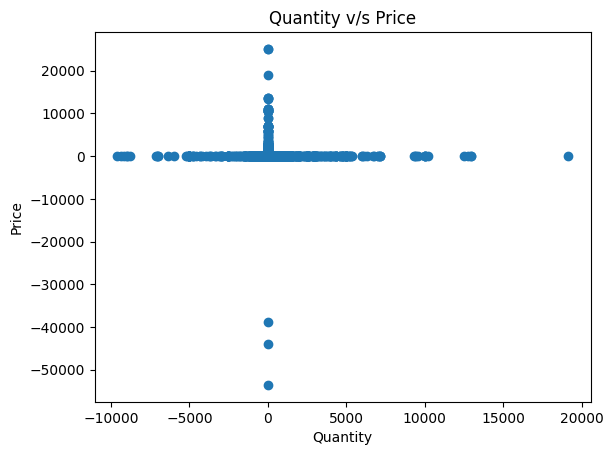

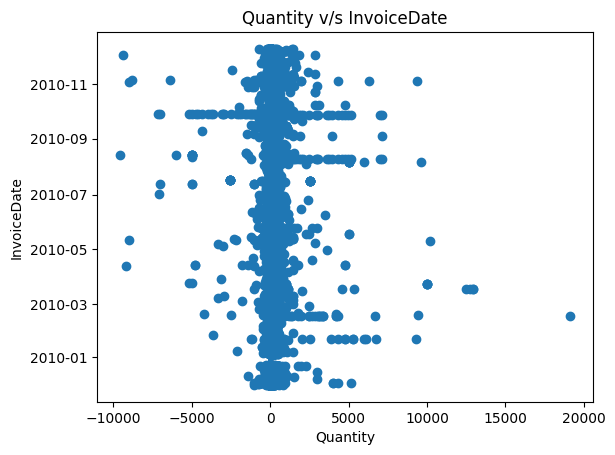

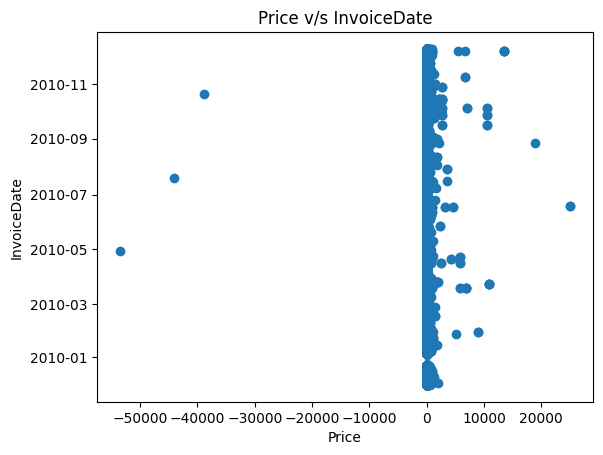

## Correlation:

## Missing Matrix:

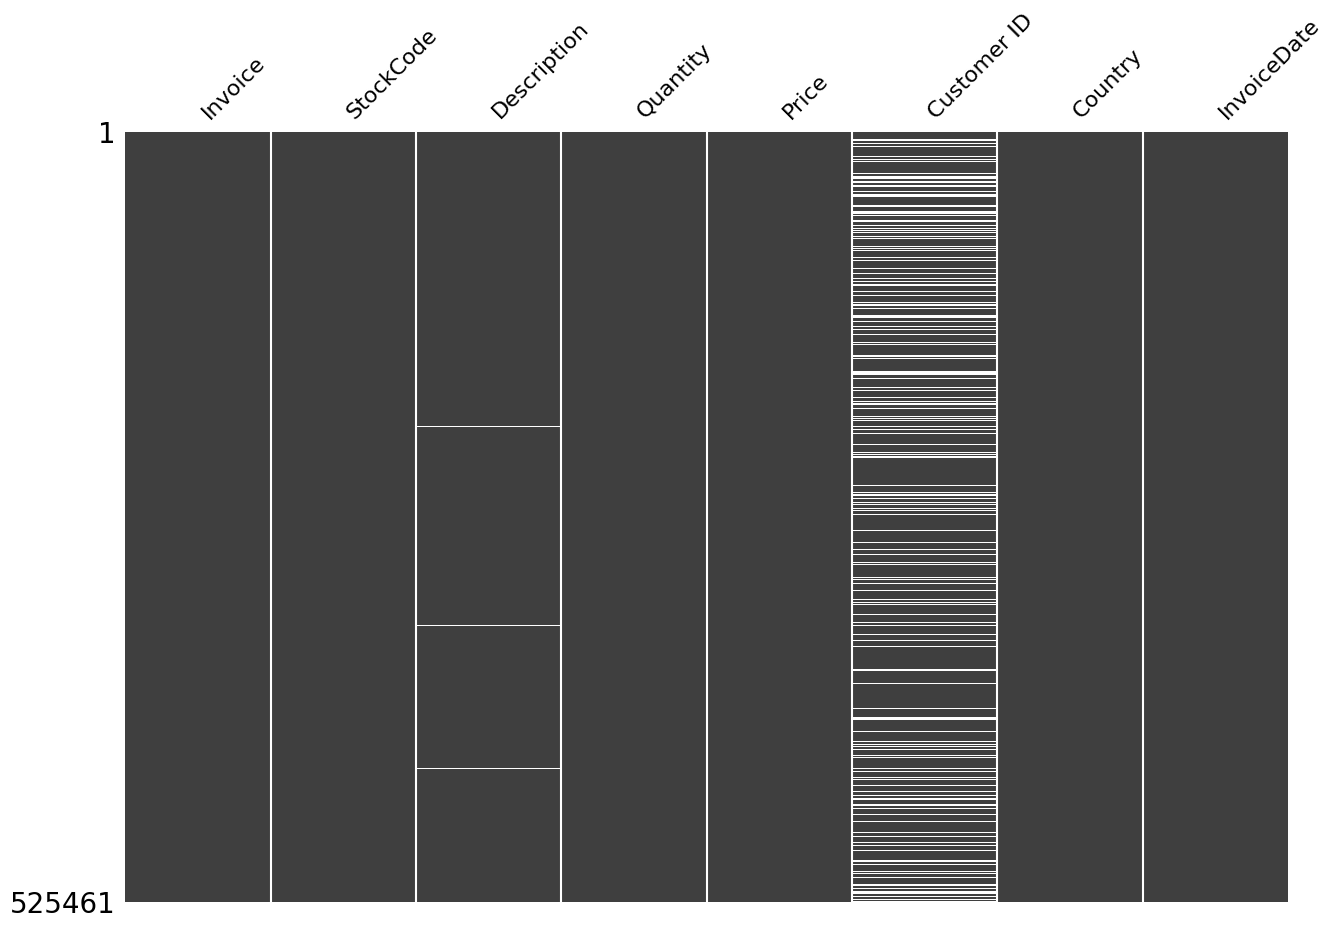

In [18]:
profile_df(df_retail)

**Existen correlaciones relevantes observadas ?**
> Vemos que no existen correlaciones observadas, siendo todos los índices de correlación prácticamente 0. Esto tiene sentido pues no debe porqué existir una relación entre el paso del tiempo (InvoiceData) con el precio y la cantidad comprada, sin embargo, tampoco debe ser así entre precio y cantidad pues el precio de un producto y su cantidad vendida está sujeto a cosas más allá como su calidad, tipo de producto, importancia para el cliente, etc...

**Qué aspectos revelan estos gráficos acerca de la limpieza de los datos?**
> Vemos que los scatter plots revelan lo que ya habíamos podido deducir en el análisis univariado anterior, donde existen muchos valores atípicos como precios y cantidades de productos negativos y, en general, muchos outliers (valores extremos con respecto al promedio/mediana) que dificultan analizar los gráficos y es necesario filtrarlos adecuadamente para hacer un análisis riguroso y que visualmente también sea descriptivo. Finalmente, en cuanto a la `Missing Matrix` vemos que efectivamente hay una cantidad muy grande de valores faltantes en `Customer ID` y algunos en mucha menor cantidad (pero no pocos) de `Description`. Así, es muy importante manejar sobre todo la columna `Customer ID` correctamente para decidir que se debe hacer con los clientes no identificados de forma exacta (para esto podría realizarse la idea comentada de usar la columna `Country` por ejemplo).

### 1.2.3 Limpieza de Datos [1 pto]

Como pudo ver en las secciones anteriores, los datos presentan valores erroneos, es por esto que se le solicita que realice una función que permita limpiar el dataset. Realice esta función en base observaciones propias y considere como **imposible tener cantidades negativas** en las ventas. Investigue sobre métodos para eliminar outliers usando pandas

Una vez realizada la función, realice nuevamente el análisis exploratorio y comente las principales diferencias.

**Respuesta:**

En base a lo comentado en el enunciado, 2 aspectos importantes a solucionar con respecto a la limpieza de los datos son tanto las cantidades negativas en las ventas así como también los precios negativos o iguales a $0$ de los productos. En este sentido, es razonable eliminar directamente las filas que presenten alguna de estas 2 condiciones ya que en teoría son imposibles que ocurran.

Por otro lado, se eliminarán outliers presentes en las columnas `Quantity` y `Price`, los cuales definimos que sean los puntos que se quedan afuera del intervalo 
$$[Q1_\text{col} - 1.5\cdot IQR_\text{col},Q3_\text{col} + 1.5\cdot IQR_\text{col}],$$
donde:
* $Q1_\text{col},Q3_\text{col}$ son el primer y tercer cuartil, respectivamente, de la columna $\text{col}$.
* $IQR_\text{col}$ es el rango intercuartílico de la columna $\text{col}$, es decir, es $Q3_\text{col} - Q1_\text{col}$.

In [19]:
def clean_dataset(df: pd.DataFrame) -> pd.DataFrame:
    df_cleaned = df.copy()

    # Consideramos solo cantidades y precios positivos
    df_cleaned = df_cleaned.query("Quantity >= 0 and Price > 0")

    # Eliminamos outliers de la columna "Quantity"
    Q1, Q3 = df_cleaned["Quantity"].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    df_cleaned = df_cleaned[(df_cleaned["Quantity"] >= Q1 - 1.5 * IQR) & (df_cleaned["Quantity"] <= Q3 + 1.5 * IQR)]

    # Repetimos el proceso para "Price"
    Q1, Q3 = df_cleaned["Price"].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    df_cleaned = df_cleaned[(df_cleaned["Price"] >= Q1 - 1.5 * IQR) & (df_cleaned["Price"] <= Q3 + 1.5 * IQR)]
    return df_cleaned

In [20]:
df_retail_cleaned = clean_dataset(df_retail)

Para el Análisis Univariado solo se analizan los casos de las columnas modificadas:

In [21]:
profile_serie(df_retail_cleaned["Quantity"])

## Quantity Profile

Type                              int64
Number of observations         424069.0
Mean                           4.848515
Std                            4.423775
Min                                 1.0
25%                                 1.0
50%                                 3.0
75%                                 7.0
Max                                23.0
Negative                              0
Negative (%)                      0.0 %
Zeros                                 0
Zeros (%)                         0.0 %
Kurt                           0.480438
Skew                           1.145286
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   424069
Duplicate rows (%)              100.0 %
Total size in memory      6785104 bytes
dtype: object

Luego de realizar una limpieza en la columna `Quantity` es posible observar que:
* La cantidad total de datos disminuyó de $525.461$ a $424.069$. Esto se tiene luego de no considerar valores _imposibles_ tanto en la columna `Quantity` como en la columna `Price` y eliminar outliers en ambas columnas.
* El promedio disminuyó desde $\approx 10,33$ a $\approx 4,84$ y lo hace estar más cerca de la mediana (la cual no se vió afectada en este proceso) que vale exactamente $3$.
* La desviación estándar disminuyó considerablemente desde $\approx 107,42$ a $\approx 4,42$, lo cual indica que luego de la limpieza los datos efectivamente están menos dispersos.
* La cantidad máxima para esta columna pasó de $19.152$ a $23$, lo cual mejora la interpretabilidad del histograma mostrado.

In [22]:
profile_serie(df_retail_cleaned["Price"])

## Price Profile

Type                            float64
Number of observations         424069.0
Mean                           2.867545
Std                            2.043843
Min                               0.001
25%                                1.25
50%                                 2.1
75%                                3.75
Max                                 8.7
Negative                              0
Negative (%)                      0.0 %
Zeros                                 0
Zeros (%)                         0.0 %
Kurt                           0.533878
Skew                           1.137037
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   424018
Duplicate rows (%)              99.99 %
Total size in memory      6785104 bytes
dtype: object

Luego de realizar una limpieza en la columna `Price` es posible observar que:
* El promedio disminuyó desde $\approx 4,68$ a $\approx 2,86$ y lo hace estar más cerca de la mediana (la cual no se vió afectada en este proceso) cuyo valor es $2.1$.
* La desviación estándar disminuyó considerablemente desde $\approx 146,12$ a $\approx 2,04$, lo cual indica que luego de la limpieza los datos efectivamente están menos dispersos.
* La cantidad máxima para esta columna pasó de $25.111$ a $8.7$, lo cual mejora la interpretabilidad del histograma mostrado.

## Bivariant Analysis:

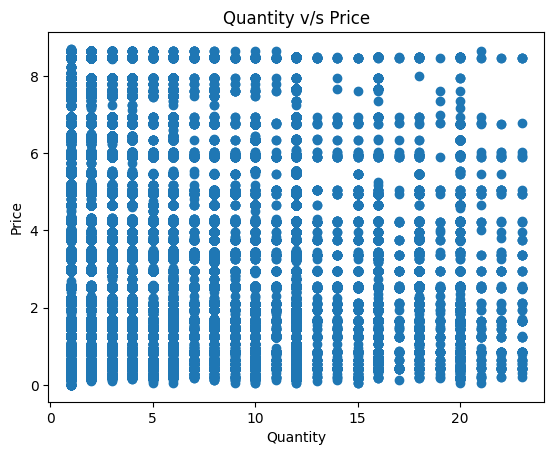

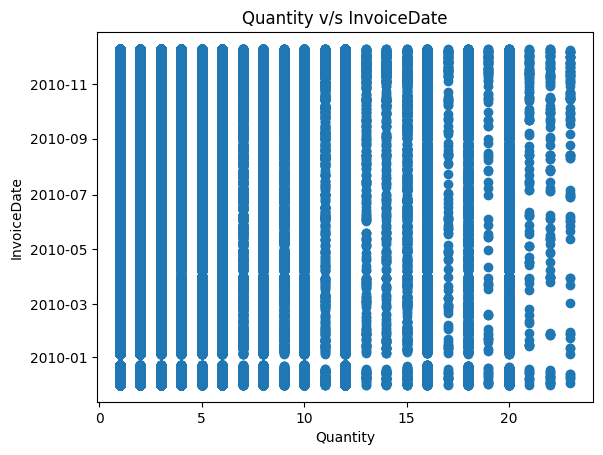

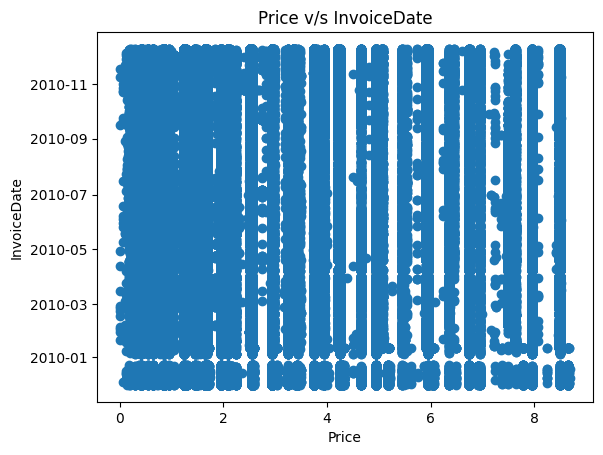

## Correlation:

## Missing Matrix:

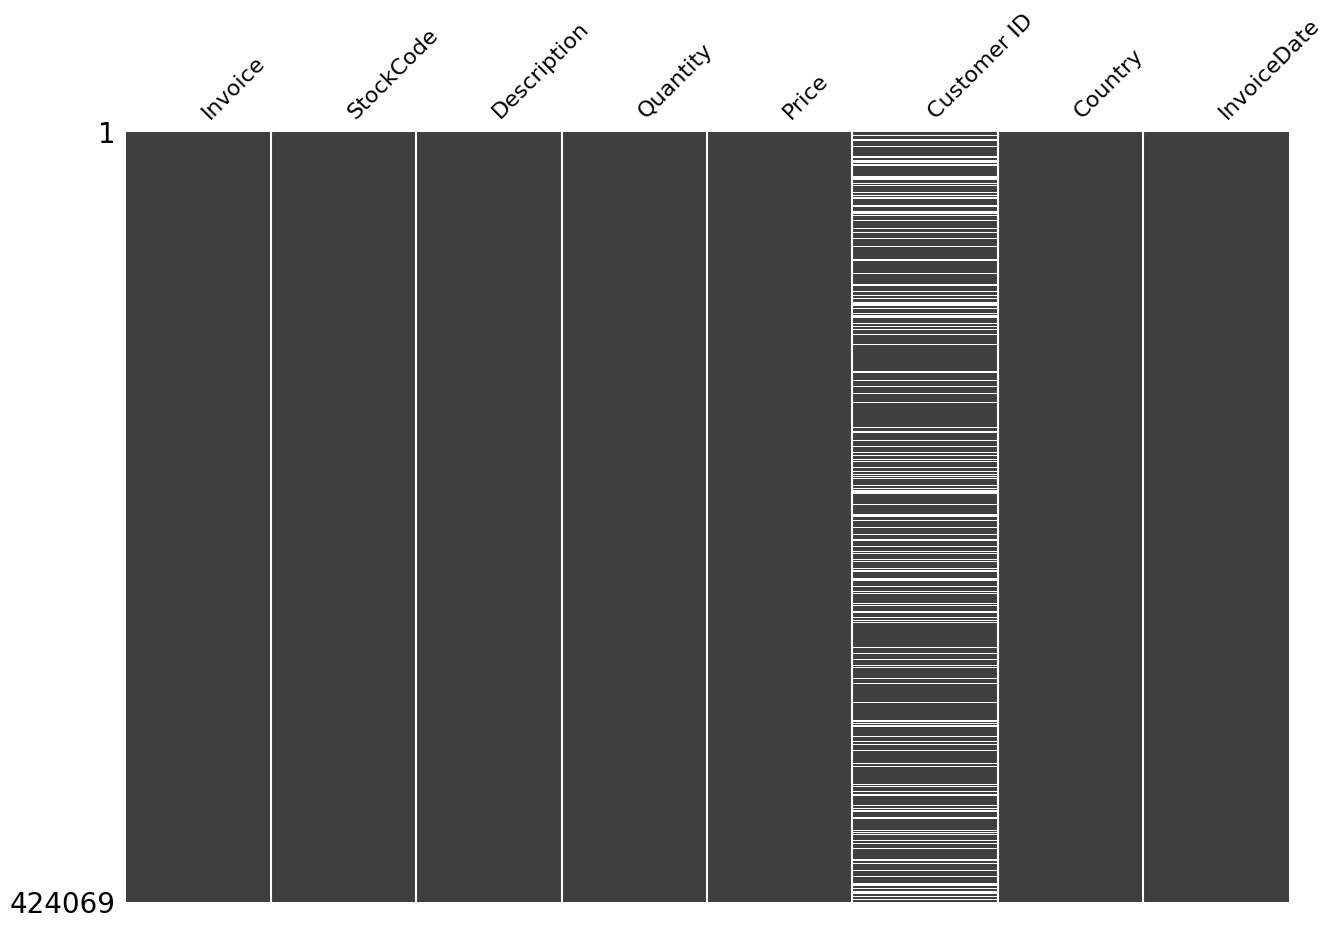

In [23]:
profile_df(df_retail_cleaned)

Luego de la limpieza se puede observar una mayor interpretabilidad en los gráficos de dispersión (aunque no mucha), así como también una falta de registros cercanos a enero de 2010 (que no se observa en la Missing Matrix).

Por otra parte, en la matriz de correlación, si bien hay un cambio en los colores de algunas celdas, la diferencia no llega a ser relevante en el sentido de que las variables siguen sin presentar correlaciones altas.

Finalmente, lo que se logra apreciar de la Missing Matrix es que de manera fortuita se arreglaron casos de productos sin descripción luego de la limpieza de datos y, por otro lado, la columna `CustomerID` siguen teniendo valores faltantes.  

**Comentario Adicional:**

No se consideró realizar una limpieza en la variable categórica `Descripción` a causa de la falta de información con respecto a ésta. Por ejemplo, se observa que productos con mismo `StockCode` pueden poseer diferentes descripciones y a priori asignarle una descripción a un artículo sin información puede ser arbitrario.  

### 1.2.4 Obtención de TOPs [0.75 ptos]

Sin considerar los comentarios realizados en la sección 1.2 , *Don Mora* les pide obtener el **Top de 30 productos que generan más ganancias** para la tienda de retail. Deben considerar todo el registro temporal presente en el dataset y entregar la información en un gráfico de barras de los ingresos/cantidades v/s el nombre de los productos (Utilice `plotly`). ¿Los artículos más vendidos son los mismos que generan más ganancias?, Comente los resultados obtenidos.

**Resultados:**

In [24]:
# Creamos una columna de ingresos (Quantity * Price)
df_retail_cleaned["Revenue"] = df_retail_cleaned["Quantity"] * df_retail_cleaned["Price"]

# Agrupamos por producto, sumamos ingresos y ordenamos de mayor a menor ingreso
top_30_revenue = df_retail_cleaned.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(30)

In [ ]:
top_30_df = top_30_revenue.reset_index().rename(columns={"Revenue": "Ingresos"})

# Creamos gráfico
fig = px.bar(
    top_30_df,
    x="Description",
    y="Ingresos",
    title="Top 30 Productos que Generan Más Ganancias",
    labels={"Ingresos": "Ingresos ($)", "Description": "Producto"},
    height=600,
)

fig.update_layout(xaxis_tickangle=-45, xaxis={"categoryorder": "total descending"})

fig.show()

In [26]:
# Top 30 por cantidad vendida
top_30_quantity = df_retail.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(30)

# Gráfico
top_30_qty_df = top_30_quantity.reset_index().rename(columns={"Quantity": "Cantidad Vendida"})

fig2 = px.bar(
    top_30_qty_df,
    x="Description",
    y="Cantidad Vendida",
    title="Top 30 Productos Más Vendidos (por Cantidad)",
    labels={"Cantidad Vendida": "Cantidad", "Description": "Producto"},
    height=600,
)

fig2.update_layout(xaxis_tickangle=-45, xaxis={"categoryorder": "total descending"})

fig2.show()

In [27]:
# Vemos si son los mismos productos
productos_revenue = set(top_30_revenue.index)
productos_quantity = set(top_30_quantity.index)

coincidentes = productos_revenue.intersection(productos_quantity)
solo_revenue = productos_revenue - productos_quantity
solo_quantity = productos_quantity - productos_revenue

print(f"Productos en ambos tops: {len(coincidentes)}")
print(f"Productos solo en top revenue: {len(solo_revenue)}")
print(f"Productos solo en top cantidad: {len(solo_quantity)}")

Productos en ambos tops: 6
Productos solo en top revenue: 24
Productos solo en top cantidad: 24


In [28]:
print("Productos en ambos tops:")
print(coincidentes)

Productos en ambos tops:
{'JUMBO BAG RED RETROSPOT', 'WHITE HANGING HEART T-LIGHT HOLDER', 'ASSORTED COLOUR BIRD ORNAMENT', 'LUNCH BAG RED SPOTTY', 'STRAWBERRY CERAMIC TRINKET BOX', 'JUMBO BAG STRAWBERRY'}


De lo observado en las celdas anteriores, solo $6$ productos están presentes en ambos tops. El caso más interesante es el caso de `WHITE HANGING HEART T-LIGHT HOLDER`, ya que es el producto más vendido y, a la misma vez, el que genera más ganancias. Haciendo esa excepción, los demás artículos más vendidos por cantidad que también aparecen en el otro top (por ingresos) tienen posiciones variables en él, por lo cual, no necesariamente se cumple que los más vendidos son los que más generan ingresos.

### 1.2.5 Visualización del registro temporal [0,75 ptos]

El dueño del retail en su afán por saber más sobre los datos de su firma les solicita que grafiquen las ventas respecto al tiempo. Con esto les aclara que durante el día tienen muchas variaciones en sus ventas, por lo que les recomienda que consideren el registro temporal como `año-mes-día`. ¿Es posible observar datos extraños?, Comente lo que observa del gráfico.

In [ ]:
def plot_ventas(dataframe):
    # Creamos una columna de fecha sin hora (año-mes-día)
    df_copy = dataframe.copy()
    df_copy["Fecha"] = df_copy["InvoiceDate"].dt.date

    # Agrupamos por fecha y sumamos cantidad vendida
    ventas_por_dia = df_copy.groupby("Fecha")["Quantity"].sum().sort_index()

    ventas_df = ventas_por_dia.reset_index().rename(columns={"Quantity": "Cantidad Vendida"})

    # Creamos el gráfico de línea
    fig = px.line(
        ventas_df,
        x="Fecha",
        y="Cantidad Vendida",
        title="Ventas Diarias (Cantidad de Artículos Vendidos)",
        labels={"Cantidad Vendida": "Artículos Vendidos", "Fecha": "Fecha"},
        height=500,
    )

    fig.update_traces(line=dict(color="#1f77b4", width=2))
    fig.update_layout(hovermode="x unified", xaxis_title="Fecha", yaxis_title="Cantidad de Artículos")

    fig.show()

    return

In [36]:
plot_ventas(df_retail_cleaned)

**Comentario:**

Se puede observar en el gráfico anterior que efectivamente la cantidad de ventas es muy variable en el período analizado (inclusive entre días próximos). Dentro de los últimos meses registrados existe una tendencia al alza en la cantidad de artículos vendidos. Una posible anomalía que se logra observar en el gráfico es la que se encuentra a inicios de enero de $2010$, ya que, tal como se veía en los gráficos de dispersión, no hay registros de ventas en esa fecha. Esto último hace que el gráfico de línea complete la información usando una línea recta y mostrando un decaimiento en la cantidad de ventas que no necesariamente sea realidad.

# Conclusión
Eso ha sido todo para el lab de hoy, recuerden que el laboratorio tiene un plazo de entrega de una semana. Cualquier duda del laboratorio, no duden en contactarnos por mail o U-cursos.

![Gracias Totales!](https://i.pinimg.com/originals/65/ae/27/65ae270df87c3c4adcea997e48f60852.gif "bruno")


<br>
<center>
<img src="https://i.kym-cdn.com/photos/images/original/001/194/195/b18.png" width=100 height=50 />
</center>
<br>

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=87110296-876e-426f-b91d-aaf681223468' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>